In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine learning models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model saving
import joblib


df = pd.read_csv("../Data/admissions_all_respiratory_conditions.csv")

df.head()

,Season,ISOyear,ISOweek,WeekBeginning,WeekEnding,Country,Pathogen,NumberAdmissionsPerWeek,RateAdmissionsPerWeek,Population
0,2020/21,2020,40,20200928,20201004,S92000003,Adenovirus,9,0.2,5408900
1,2020/21,2020,40,20200928,20201004,S92000003,COVID-19,187,3.5,5408900
2,2020/21,2020,40,20200928,20201004,S92000003,HMPV,0,0.0,5408900
3,2020/21,2020,40,20200928,20201004,S92000003,Influenza (All),2,0.0,5408900
4,2020/21,2020,40,20200928,20201004,S92000003,Influenza A,2,0.0,5408900


In [2]:
df.columns

Index(['Season', 'ISOyear', 'ISOweek', 'WeekBeginning', 'WeekEnding',
       'Country', 'Pathogen', 'NumberAdmissionsPerWeek',
       'RateAdmissionsPerWeek', 'Population'],
      dtype='object')

In [4]:
df["Pathogen"].unique()

array(['Adenovirus', 'COVID-19', 'HMPV', 'Influenza (All)', 'Influenza A',
       'Influenza B', 'Mycoplasma pneumoniae', 'Parainfluenza (Any Type)',
       'RSV', 'Rhinovirus', 'Seasonal coronavirus'], dtype=object)

In [5]:
influenza_df = df[df["Pathogen"].isin(["Influenza A", "Influenza B"])].copy()

influenza_df.head()

,Season,ISOyear,ISOweek,WeekBeginning,WeekEnding,Country,Pathogen,NumberAdmissionsPerWeek,RateAdmissionsPerWeek,Population
4,2020/21,2020,40,20200928,20201004,S92000003,Influenza A,2,0.0,5408900
5,2020/21,2020,40,20200928,20201004,S92000003,Influenza B,0,0.0,5408900
15,2020/21,2020,41,20201005,20201011,S92000003,Influenza A,2,0.0,5408900
16,2020/21,2020,41,20201005,20201011,S92000003,Influenza B,0,0.0,5408900
26,2020/21,2020,42,20201012,20201018,S92000003,Influenza A,0,0.0,5408900


In [6]:
influenza_df["Pathogen"].unique()

array(['Influenza A', 'Influenza B'], dtype=object)

In [7]:
# Check the values first
print(df["Country"].unique())
print(df["Pathogen"].unique())

['S92000003']
['Adenovirus' 'COVID-19' 'HMPV' 'Influenza (All)' 'Influenza A'
 'Influenza B' 'Mycoplasma pneumoniae' 'Parainfluenza (Any Type)' 'RSV'
 'Rhinovirus' 'Seasonal coronavirus']


In [8]:
df_scotland = df[df["Country"] == "S92000003"].copy()

print(df_scotland["Country"].unique())

['S92000003']


In [9]:
influenza_df = df_scotland[
    df_scotland["Pathogen"].isin(["Influenza A", "Influenza B"])
].copy()

print(influenza_df["Pathogen"].unique())

['Influenza A' 'Influenza B']


In [10]:
weekly_influenza = influenza_df.groupby(
    ["WeekBeginning"], as_index=False
)["NumberAdmissionsPerWeek"].sum()

weekly_influenza = weekly_influenza.rename(
    columns={"NumberAdmissionsPerWeek": "admissions"}
)

weekly_influenza.head()

,WeekBeginning,admissions
0,20200928,2
1,20201005,2
2,20201012,0
3,20201019,0
4,20201026,2


In [11]:
weekly_influenza["WeekBeginning"] = pd.to_datetime(
    weekly_influenza["WeekBeginning"].astype(str),
    format="%Y%m%d"
)

weekly_influenza = weekly_influenza.sort_values("WeekBeginning").reset_index(drop=True)

weekly_influenza.head()

,WeekBeginning,admissions
0,2020-09-28,2
1,2020-10-05,2
2,2020-10-12,0
3,2020-10-19,0
4,2020-10-26,2


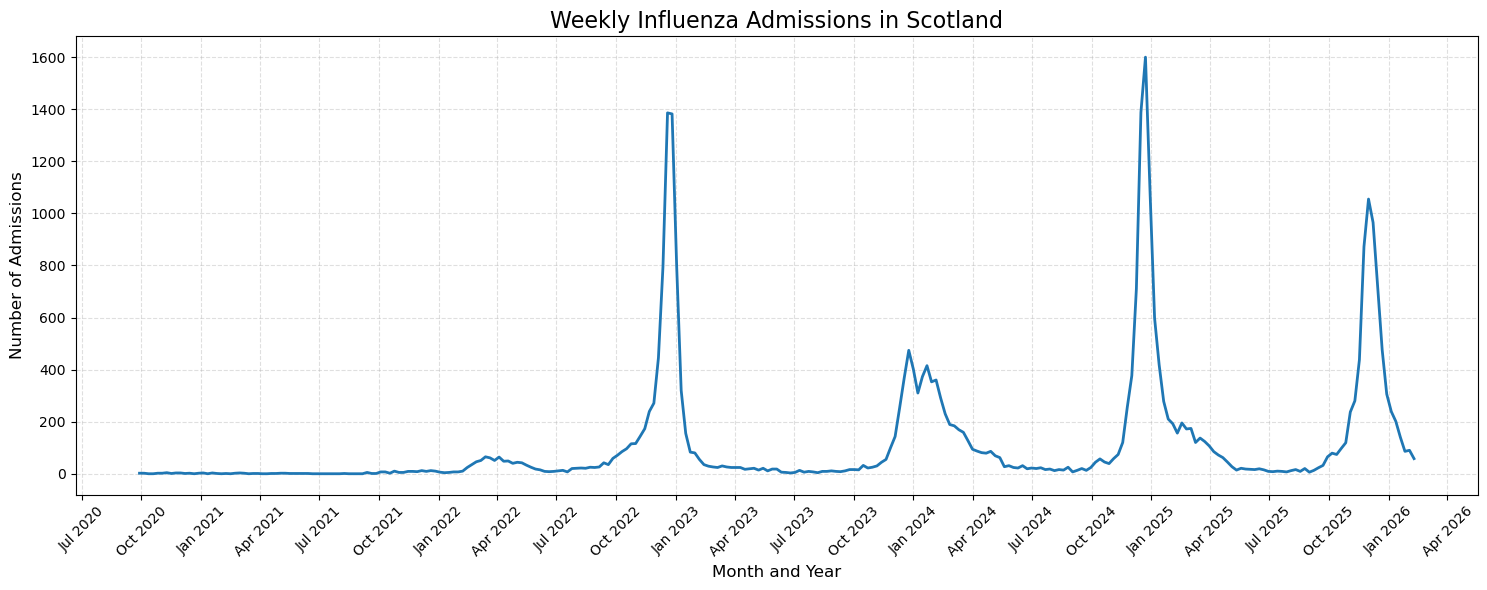

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))
plt.plot(weekly_influenza["WeekBeginning"], weekly_influenza["admissions"], linewidth=2)

plt.title("Weekly Influenza Admissions in Scotland", fontsize=16)
plt.xlabel("Month and Year", fontsize=12)
plt.ylabel("Number of Admissions", fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
weekly_influenza["lag_1"] = weekly_influenza["admissions"].shift(1)
weekly_influenza["lag_2"] = weekly_influenza["admissions"].shift(2)
weekly_influenza["lag_3"] = weekly_influenza["admissions"].shift(3)

weekly_influenza.head(10)

,WeekBeginning,admissions,lag_1,lag_2,lag_3
0,2020-09-28,2,NaN,NaN,NaN
1,2020-10-05,2,2.0,NaN,NaN
2,2020-10-12,0,2.0,2.0,NaN
3,2020-10-19,0,0.0,2.0,2.0
4,2020-10-26,2,0.0,0.0,2.0
5,2020-11-02,2,2.0,0.0,0.0
6,2020-11-09,4,2.0,2.0,0.0
7,2020-11-16,1,4.0,2.0,2.0
8,2020-11-23,3,1.0,4.0,2.0
9,2020-11-30,3,3.0,1.0,4.0


In [50]:
weekly_influenza["target"] = weekly_influenza["admissions"].shift(-2)

weekly_influenza.head(10)

,WeekBeginning,admissions,lag_1,lag_2,lag_3,target
0,2020-09-28,2,NaN,NaN,NaN,0.0
1,2020-10-05,2,2.0,NaN,NaN,0.0
2,2020-10-12,0,2.0,2.0,NaN,2.0
3,2020-10-19,0,0.0,2.0,2.0,2.0
4,2020-10-26,2,0.0,0.0,2.0,4.0
5,2020-11-02,2,2.0,0.0,0.0,1.0
6,2020-11-09,4,2.0,2.0,0.0,3.0
7,2020-11-16,1,4.0,2.0,2.0,3.0
8,2020-11-23,3,1.0,4.0,2.0,1.0
9,2020-11-30,3,3.0,1.0,4.0,2.0


In [16]:
weekly_model_data.to_csv("../Outputs/weekly_influenza_model_data.csv", index=False)

In [17]:
X = weekly_model_data[["lag_1", "lag_2", "lag_3"]]
y = weekly_model_data["target"]

In [18]:
split_index = int(len(weekly_model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (220, 3)
X_test shape: (56, 3)
y_train shape: (220,)
y_test shape: (56,)


In [19]:
moving_avg_pred = X_test.mean(axis=1)

In [20]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [21]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [22]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print("-" * 30)

In [23]:
evaluate_model("Moving Average", y_test, moving_avg_pred)
evaluate_model("Ridge Regression", y_test, ridge_pred)
evaluate_model("Random Forest", y_test, rf_pred)

Moving Average
MAE: 180.75
RMSE: 319.35
------------------------------
Ridge Regression
MAE: 95.40
RMSE: 184.14
------------------------------
Random Forest
MAE: 60.63
RMSE: 91.27
------------------------------


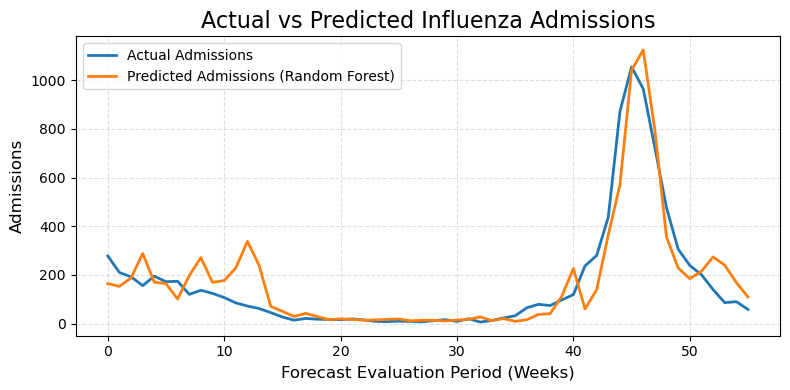

In [49]:
plt.figure(figsize=(8, 4))
plt.plot(y_test.values, label="Actual Admissions", linewidth=2)
plt.plot(rf_pred, label="Predicted Admissions (Random Forest)", linewidth=2)

plt.title("Actual vs Predicted Influenza Admissions", fontsize=16)
plt.xlabel("Forecast Evaluation Period (Weeks)", fontsize=12)
plt.ylabel("Admissions", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

  Feature  Importance
0   lag_1    0.667680
2   lag_3    0.247274
1   lag_2    0.085046


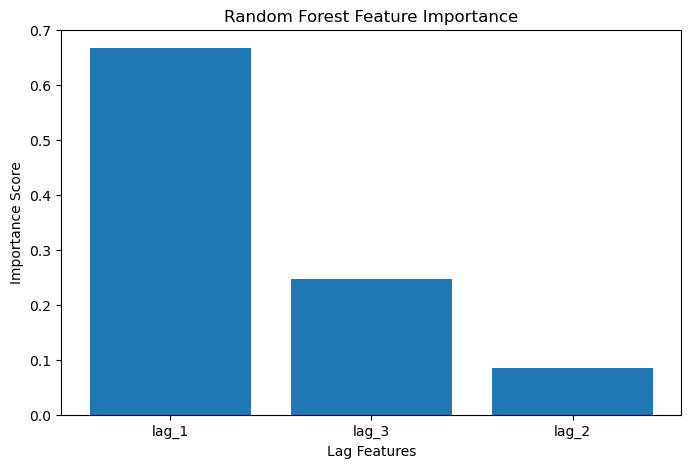

In [26]:
plt.figure(figsize=(8,5))

plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.title("Random Forest Feature Importance")
plt.xlabel("Lag Features")
plt.ylabel("Importance Score")

plt.show()

In [27]:
low_threshold = weekly_model_data["admissions"].quantile(0.40)
high_threshold = weekly_model_data["admissions"].quantile(0.70)

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)

Low threshold: 16.0
High threshold: 65.0


In [28]:
def classify_risk(prediction, low_threshold, high_threshold):

    if prediction < low_threshold:
        return "Low Risk"
    
    elif prediction <= high_threshold:
        return "Medium Risk"
    
    else:
        return "High Risk"

In [29]:
sample_prediction = rf_pred[0]

print(sample_prediction)
print(classify_risk(sample_prediction, low_threshold, high_threshold))

164.22
High Risk


In [30]:
joblib.dump(rf_model, "../Models/random_forest_model.pkl")

['../Models/random_forest_model.pkl']

In [31]:
thresholds = {
    "low_threshold": low_threshold,
    "high_threshold": high_threshold
}

joblib.dump(thresholds, "../Models/risk_thresholds.pkl")

['../Models/risk_thresholds.pkl']

In [32]:
def directional_accuracy(y_true, y_pred):
    actual_direction = np.sign(np.diff(y_true))
    predicted_direction = np.sign(np.diff(y_pred))
    return (actual_direction == predicted_direction).mean()

In [33]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    da = directional_accuracy(np.array(y_true), np.array(y_pred))

    print(f"{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"Directional Accuracy: {da:.2%}")
    print("-" * 30)

In [34]:
evaluate_model("Moving Average", y_test, moving_avg_pred)
evaluate_model("Ridge Regression", y_test, ridge_pred)
evaluate_model("Random Forest", y_test, rf_pred)

Moving Average
MAE: 180.75
RMSE: 319.35
Directional Accuracy: 65.45%
------------------------------
Ridge Regression
MAE: 95.40
RMSE: 184.14
Directional Accuracy: 45.45%
------------------------------
Random Forest
MAE: 60.63
RMSE: 91.27
Directional Accuracy: 56.36%
------------------------------


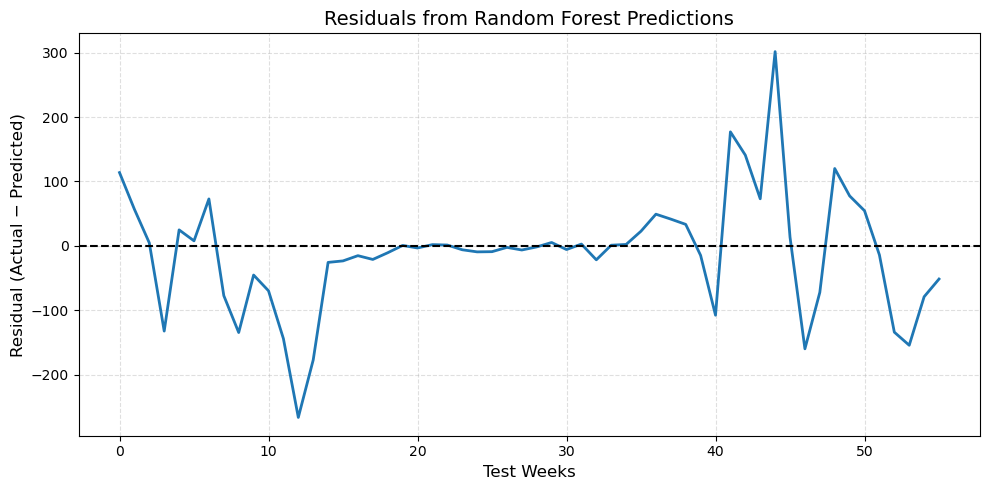

In [36]:
plt.figure(figsize=(10,5))

plt.plot(residuals, linewidth=2)
plt.axhline(y=0, color='black', linestyle='--')

plt.title("Residuals from Random Forest Predictions", fontsize=14)
plt.xlabel("Test Weeks", fontsize=12)
plt.ylabel("Residual (Actual − Predicted)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [37]:
weekly_model_data.to_csv("../Outputs/weekly_influenza_model_data.csv", index=False)

In [38]:
feature_importance.to_csv("../Outputs/feature_importance.csv", index=False)

In [39]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_RF": rf_pred
})

results_df.to_csv("../Outputs/random_forest_predictions.csv", index=False)

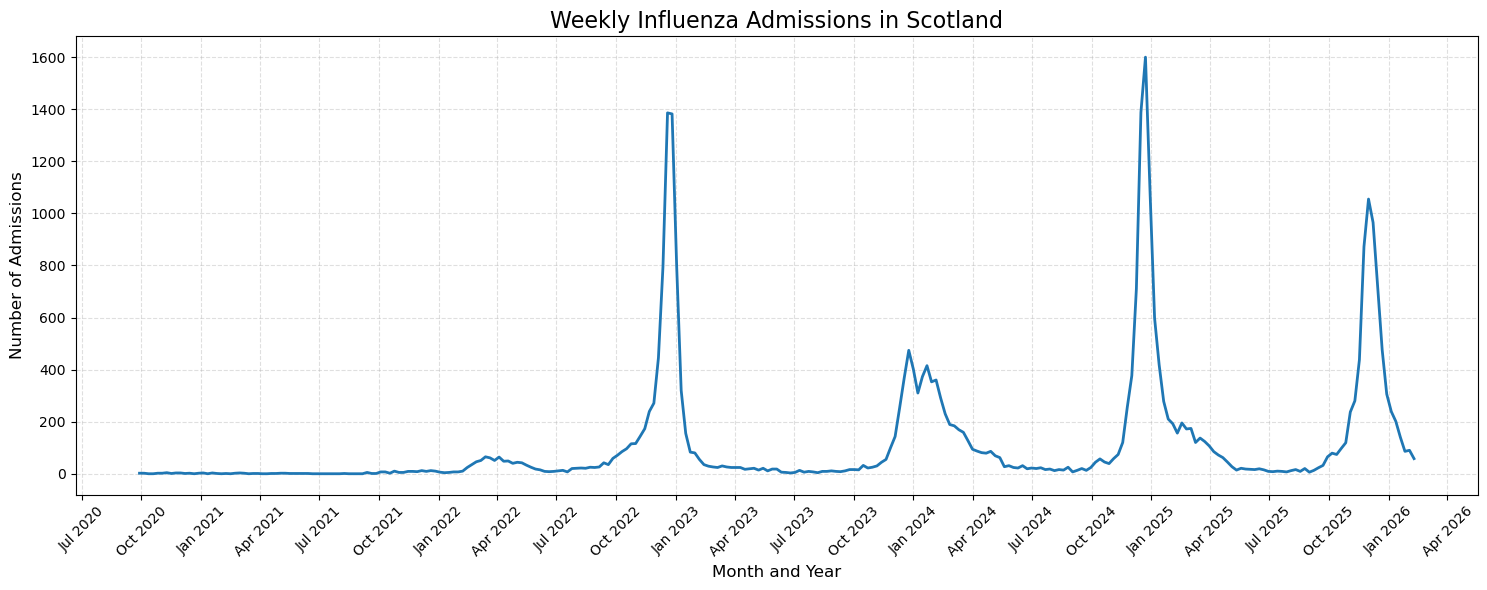

In [40]:
plt.figure(figsize=(15, 6))
plt.plot(weekly_influenza["WeekBeginning"], weekly_influenza["admissions"], linewidth=2)

plt.title("Weekly Influenza Admissions in Scotland", fontsize=16)
plt.xlabel("Month and Year", fontsize=12)
plt.ylabel("Number of Admissions", fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../Outputs/weekly_influenza_admissions.png", dpi=300)
plt.show()

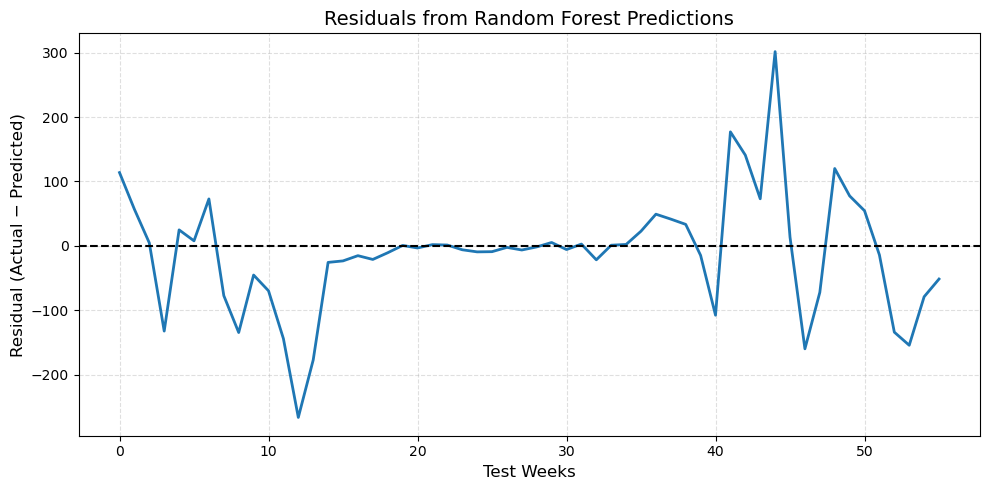

In [42]:
plt.figure(figsize=(10,5))

plt.plot(residuals, linewidth=2)

plt.axhline(y=0, color='black', linestyle='--')

plt.title("Residuals from Random Forest Predictions", fontsize=14)
plt.xlabel("Test Weeks", fontsize=12)
plt.ylabel("Residual (Actual − Predicted)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../Outputs/random_forest_residuals.png", dpi=300)
plt.show()

In [43]:
weekly_model_data.to_csv("../Outputs/weekly_influenza_model_data.csv", index=False)

feature_importance.to_csv("../Outputs/feature_importance.csv", index=False)

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_RF": rf_pred
})
results_df.to_csv("../Outputs/random_forest_predictions.csv", index=False)

In [45]:
import joblib

joblib.dump(rf_model, "../Models/random_forest_model.pkl")

['../Models/random_forest_model.pkl']

In [46]:
thresholds = {
    "low_threshold": low_threshold,
    "high_threshold": high_threshold
}

joblib.dump(thresholds, "../Models/risk_thresholds.pkl")

['../Models/risk_thresholds.pkl']